# LushProtein — Decile: Contribution Margin & Order Frequency (5 Tiers)

**Goal:** Re-decile customers using the founder's requested formula, on the freshly cleaned `outputs_finals/` data.

**Contribution Margin formula (as scoped with the founder):**
```
Contribution Margin = Net Revenue − COGS
```
Variable Fulfillment Costs and Refunds are **excluded** — no reliable per-order data exists for either
(see markdown notes below for why). Discounts are **already netted into revenue** by Shopify's export format,
so no separate subtraction is needed.

**Two independent decile rankings, both D1–D5 (not D1–D10 like draft 1):**
- **Contribution Margin Decile** — ranked by `true_gross_profit` (Revenue − COGS). D1 = highest.
- **Order Frequency (AOF) Decile** — ranked by `finals_orders` (number of orders placed). D1 = most frequent.

**Customer pool:** `finals_eligible == True` AND NOT 100%-Marketplace accounts (see Section 2 for why).

---

### Why D1–D5 instead of D1–D10 this time

This is a direct ask from the founder meeting — 5 tiers instead of 10. With a pool of ~4,290 customers,
5 tiers still give ~858 customers per group, large enough for reliable analysis, and simpler for
non-technical stakeholders to act on (5 customer segments are easier to build campaigns around than 10).

### Why no Fulfillment Cost or Refund terms

- **Variable Fulfillment Costs**: no pick/pack/ship cost-per-order data exists anywhere in the dataset.
  `Price: Total Shipping` is what the *customer paid*, not what it *cost* LushProtein to fulfill — using it
  would misrepresent fulfillment cost as fulfillment revenue. Excluded until the founder provides a real figure.
- **Refunds**: no refund dollar amount exists. Only a binary signal (`Payment: Status == 'partially_refunded'`,
  61 orders) is available, with no associated amount. Excluded until quantifiable.

### Why discounts need no separate subtraction

Shopify's `Price: Total` field is **already net of discounts** at export time — it is calculated as
`(unit price × quantity) − discount`, not the pre-discount sticker price. You can verify this yourself:
`orders["Price: Total"] + orders["Price: Total Discount"]` reconstructs the pre-discount price, which only
makes sense if `Price: Total` was already reduced by the discount. So "Net Revenue" in the formula is simply
`Price: Total` as-is — no further adjustment needed.


## 0. Setup

In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR   = Path(".").resolve().parent   # assumes notebook is inside EDA/
FINALS_DIR = BASE_DIR / "EDA" / "outputs_finals"

N_TIERS = 5 # founder-requested: 5 groups instead of 10

print("Finals dir:", FINALS_DIR)
print("Parquet files:", [f.name for f in FINALS_DIR.glob("*.parquet")])

Finals dir: /Users/shwe/Desktop/CustomerAnalytics_Project/lushprotein/EDA/outputs_finals
Parquet files: ['lines.parquet', 'discounts.parquet', 'rc_orders.parquet', 'lines_sku_analysis.parquet', 'products.parquet', 'orders.parquet', 'rc_reactivated.parquet', 'rc_checkout.parquet', 'rc_recurring.parquet', 'customers.parquet', 'rc_churned.parquet']


## 1. Load Pre-Cleaned Data

No DQ cleaning needed here — `outputs_finals/` is already cleaned (DQ-02/03/04, LP-F01–F04, COGS-enriched
by `13_build_finals_datasets.py` + `enrich_finals_with_margin.py`). We only load and inspect.

In [2]:
orders = pd.read_parquet(FINALS_DIR / "orders.parquet")
cust   = pd.read_parquet(FINALS_DIR / "customers.parquet")

print(f"Orders (finals, COGS-enriched) : {len(orders):,}")
print(f"Customers (finals, COGS-enriched): {len(cust):,}")
print()
print(f"finals_eligible customers : {(cust['finals_eligible']==True).sum():,}")
print()
print("Key columns already present:")
print(" true_gross_profit — Revenue minus COGS, our Contribution Margin base")
print(" finals_orders — order count within the finals-eligible window (our AOF metric)")
print(" cogs_coverage_pct — % of this customer's revenue that has real COGS (vs 40% proxy fallback)")

Orders (finals, COGS-enriched) : 8,955
Customers (finals, COGS-enriched): 5,694

finals_eligible customers : 5,694

Key columns already present:
 true_gross_profit — Revenue minus COGS, our Contribution Margin base
 finals_orders — order count within the finals-eligible window (our AOF metric)
 cogs_coverage_pct — % of this customer's revenue that has real COGS (vs 40% proxy fallback)


## 2. Marketplace Exclusion — Why and How

**The problem:** `outputs_finals/` is cleaned for data-quality and business-rule issues (DQ drops, promo
months, bulk SKU, heavy discounts) — but it does **not** exclude 100%-Marketplace (Shopee/Lazada) accounts.
We need to check and reapply this ourselves, same as draft 1.

**Why it matters — concrete example below.**

In [3]:
# ── Channel mix per customer ───────────────────────────────────────────────────
cust_channel_mix = (orders.groupby("customer_id")["channel"].value_counts(normalize=True).unstack(fill_value=0))

all_marketplace_ids = set(cust_channel_mix[cust_channel_mix.get("Marketplace", pd.Series(0, index=cust_channel_mix.index)) == 1.0].index.astype(str))

cust["is_all_marketplace"] = cust["customer_id"].astype(str).isin(all_marketplace_ids)

print(f"Channel breakdown of all orders:")
print(orders["channel"].value_counts().to_string())
print()
print(f"Customers with 100% Marketplace orders : {len(all_marketplace_ids):,}")
print(f"Of finals_eligible customers, all-marketplace : {(cust['finals_eligible'] & cust['is_all_marketplace']).sum():,}")

Channel breakdown of all orders:
channel
Direct / Organic    3293
Subscription        3044
Marketplace         2167
Paid Social          373
Email                 52
Affiliate             23
Paid Search            3

Customers with 100% Marketplace orders : 1,404
Of finals_eligible customers, all-marketplace : 1,404


### Concrete Example — Why This Customer Cannot Be Treated as a Real Consumer

Below is the single largest all-Marketplace account in the dataset. Notice:
- **524 separate orders**, each with its own unique `order_id`
- **Multiple orders placed on the exact same day**, repeated daily for months
- **Order values swing wildly** (S$29.90 to S$438 in the same week) — no personal buying rhythm

No single human shopper behaves like this. This is the fingerprint of a Shopee storefront account
absorbing many different real buyers' orders into one Shopify `customer_id` — not one loyal customer.

In [4]:
mkt_orders = orders[orders["channel"] == "Marketplace"].copy()

orders_per_mkt_cust = mkt_orders.groupby("customer_id")["order_id"].count()
print("Orders-per-customer distribution among Marketplace accounts:")
print(orders_per_mkt_cust.describe().to_string())
print()
print(f" Median = {orders_per_mkt_cust.median():.0f} order  →  most are genuine one-time Shopee shoppers")
print(f" Max = {orders_per_mkt_cust.max():.0f} orders →  but extreme outliers exist (aggregator pattern)")
print()

# Show the worst offender as a concrete example
top_mkt_cust = orders_per_mkt_cust.idxmax()
example = mkt_orders[mkt_orders["customer_id"] == top_mkt_cust][["order_id", "order_date", "Price: Total", "Name"]].sort_values("order_date").head(10)

print(f"EXAMPLE — customer_id {top_mkt_cust} ({orders_per_mkt_cust.max()} total orders):")
print(example.to_string(index=False))
print("...")
print(f"\nDecision: exclude ALL {len(all_marketplace_ids):,} all-Marketplace customers from the decile pool")
print("(consistent with draft 1 methodology — simplicity over trying to separate the few outliers from genuine one-time buyers)")

Orders-per-customer distribution among Marketplace accounts:
count    1404.000000
mean        1.543447
std        13.964530
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       524.000000

 Median = 1 order  →  most are genuine one-time Shopee shoppers
 Max = 524 orders →  but extreme outliers exist (aggregator pattern)

EXAMPLE — customer_id 7888450879743 (524 total orders):
     order_id                order_date  Price: Total     Name
6038114042111 2025-03-05 16:00:00+00:00          29.9 LP-42767
6038154445055 2025-03-05 16:00:00+00:00         119.0 LP-42769
6038155100415 2025-03-05 16:00:00+00:00          59.8 LP-42770
6038210871551 2025-03-05 16:00:00+00:00         238.0 LP-42773
6038301638911 2025-03-05 16:00:00+00:00          89.9 LP-42774
6038351249663 2025-03-05 16:00:00+00:00         219.0 LP-42775
6039815487743 2025-03-06 16:00:00+00:00         438.0 LP-42788
6040719524095 2025-03-07 16:00:00+00:00         169.9 LP-42795
6041123848447

## 3. Build the Final Customer Pool

In [5]:
f_finals_eligible = cust["finals_eligible"] == True
f_not_marketplace = ~cust["is_all_marketplace"]

final_mask = f_finals_eligible & f_not_marketplace
df = cust[final_mask].copy()

print("Filter funnel:")
print(f"  Base customers (outputs_finals) : {len(cust):>6,}")
print(f"  finals_eligible : {f_finals_eligible.sum():>6,}")
print(f"  - excl. all-marketplace accounts : {final_mask.sum():>6,}")
print(f"  ─────────────────────────────────────────────")
print(f"  Final decile pool : {len(df):>6,} customers")
print()
print(f"Contribution margin range : S${df['true_gross_profit'].min():,.2f} – S${df['true_gross_profit'].max():,.2f}")
print(f"Order count range : {df['finals_orders'].min()} – {df['finals_orders'].max()}")
print()
neg_count = (df["true_gross_profit"] < 0).sum()
print(f"Note: {neg_count} customers have negative contribution margin")
print(" (sold below cost — likely loss-leader/promo SKUs with thin or negative real margin)")

Filter funnel:
  Base customers (outputs_finals) :  5,694
  finals_eligible :  5,694
  - excl. all-marketplace accounts :  4,290
  ─────────────────────────────────────────────
  Final decile pool :  4,290 customers

Contribution margin range : S$-29.93 – S$2,796.69
Order count range : 1 – 38

Note: 9 customers have negative contribution margin
 (sold below cost — likely loss-leader/promo SKUs with thin or negative real margin)


## 4. Build the Two Deciles (5 Tiers Each)

D1 = best (highest contribution margin / most frequent orders) in both. Equal-sized groups via `pd.qcut` on ranks.

In [6]:
def assign_decile(series: pd.Series, n_tiers: int = N_TIERS) -> pd.Series:
    """D1 = best (highest value), D[n] = worst. Ties broken deterministically."""
    ranks = series.rank(method="first", ascending=True)
    return pd.qcut(
        ranks,
        q=n_tiers,
        labels=[f"D{i}" for i in range(n_tiers, 0, -1)])

df["contribution_margin_decile"] = assign_decile(df["true_gross_profit"])
df["order_freq_decile"] = assign_decile(df["finals_orders"])

print("Contribution Margin Decile distribution:")
print(df["contribution_margin_decile"].value_counts().sort_index().to_string())
print()
print("Order Frequency Decile distribution:")
print(df["order_freq_decile"].value_counts().sort_index().to_string())

Contribution Margin Decile distribution:
contribution_margin_decile
D5    858
D4    858
D3    858
D2    858
D1    858

Order Frequency Decile distribution:
order_freq_decile
D5    858
D4    858
D3    858
D2    858
D1    858


## 5. Decile Summary — Contribution Margin

In [7]:
cm_summary = (
    df.groupby("contribution_margin_decile", observed=False)
    .agg(
        n_customers = ("customer_id", "count"),
        total_cm = ("true_gross_profit", "sum"),
        avg_cm = ("true_gross_profit", "mean"),
        median_cm = ("true_gross_profit", "median"),
        avg_revenue = ("finals_revenue", "mean"),
        avg_orders = ("finals_orders", "mean"),
        avg_margin_pct = ("avg_margin_pct", "mean"),).reset_index())

total_cm_pool = cm_summary["total_cm"].sum()
cm_summary["pct_of_total_cm"] = cm_summary["total_cm"] / total_cm_pool
cm_summary["cum_pct_cm"]      = cm_summary["pct_of_total_cm"].cumsum()

fmt_cm = {
    "avg_cm": lambda x: f"S${x:,.2f}",
    "median_cm": lambda x: f"S${x:,.2f}",
    "avg_revenue": lambda x: f"S${x:,.2f}",
    "avg_orders": lambda x: f"{x:.1f}",
    "avg_margin_pct": lambda x: f"{x:.1%}",
    "pct_of_total_cm":lambda x: f"{x:.1%}",
    "cum_pct_cm": lambda x: f"{x:.1%}",}

print(f"DECILE — BY CONTRIBUTION MARGIN  (pool = {len(df):,} customers | total CM = S${total_cm_pool:,.0f})")
print()
display_cols_cm = ["contribution_margin_decile", "n_customers", "avg_cm", "median_cm", "avg_revenue", "avg_orders", "avg_margin_pct", "pct_of_total_cm", "cum_pct_cm"]
print(cm_summary[display_cols_cm].to_string(index=False, formatters=fmt_cm))
print()
d1_pct = cm_summary.loc[cm_summary["contribution_margin_decile"]=="D1", "pct_of_total_cm"].values[0]
print(f" Top 20% (D1) of customers generate {d1_pct:.1%} of total contribution margin")

DECILE — BY CONTRIBUTION MARGIN  (pool = 4,290 customers | total CM = S$341,853)

contribution_margin_decile  n_customers   avg_cm median_cm avg_revenue avg_orders avg_margin_pct pct_of_total_cm cum_pct_cm
                        D5          858   S$8.87    S$8.02     S$19.25        1.1          49.3%            2.2%       2.2%
                        D4          858  S$29.66   S$28.74     S$52.75        1.1          60.7%            7.4%       9.7%
                        D3          858  S$48.59   S$48.41     S$74.48        1.2          69.3%           12.2%      21.9%
                        D2          858  S$81.25   S$80.92    S$122.04        1.5          70.5%           20.4%      42.3%
                        D1          858 S$230.05  S$164.25    S$374.69        3.1          69.1%           57.7%     100.0%

 Top 20% (D1) of customers generate 57.7% of total contribution margin


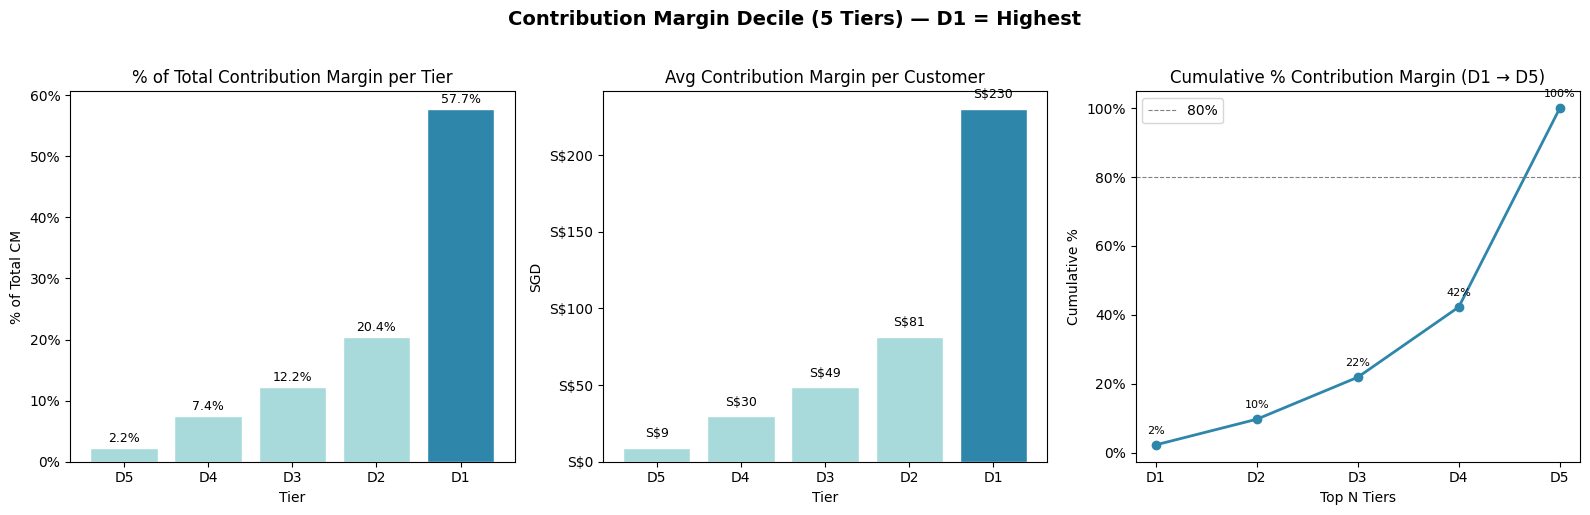

Saved: decile_contribution_margin.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Contribution Margin Decile (5 Tiers) — D1 = Highest", fontsize=14, fontweight="bold", y=1.02)

tiers_cm = cm_summary["contribution_margin_decile"].astype(str)
colors_cm = ["#2E86AB" if t == "D1" else "#A8DADC" for t in tiers_cm]

ax = axes[0]
bars = ax.bar(tiers_cm, cm_summary["pct_of_total_cm"] * 100, color=colors_cm, edgecolor="white")
ax.set_title("% of Total Contribution Margin per Tier")
ax.set_xlabel("Tier"); ax.set_ylabel("% of Total CM")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars, cm_summary["pct_of_total_cm"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{val:.1%}", ha="center", va="bottom", fontsize=9)

ax = axes[1]
bars = ax.bar(tiers_cm, cm_summary["avg_cm"], color=colors_cm, edgecolor="white")
ax.set_title("Avg Contribution Margin per Customer")
ax.set_xlabel("Tier"); ax.set_ylabel("SGD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S${x:,.0f}"))
for bar, val in zip(bars, cm_summary["avg_cm"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f"S${val:,.0f}", ha="center", va="bottom", fontsize=9)

ax = axes[2]
ax.plot(range(1, N_TIERS+1), cm_summary["cum_pct_cm"] * 100, marker="o", color="#2E86AB", linewidth=2)
ax.axhline(80, color="gray", linestyle="--", linewidth=0.8, label="80%")
ax.set_title("Cumulative % Contribution Margin (D1 → D5)")
ax.set_xlabel("Top N Tiers"); ax.set_ylabel("Cumulative %")
ax.set_xticks(range(1, N_TIERS+1)); ax.set_xticklabels([f"D{i}" for i in range(1, N_TIERS+1)])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend()
for x, y in zip(range(1, N_TIERS+1), cm_summary["cum_pct_cm"] * 100):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(FINALS_DIR / "decile_contribution_margin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile_contribution_margin.png")

## 6. Decile Summary — Order Frequency (AOF)

In [20]:
freq_summary = (
    df.groupby("order_freq_decile", observed=False)
    .agg(
        n_customers = ("customer_id", "count"),
        total_orders = ("finals_orders", "sum"),
        avg_orders = ("finals_orders", "mean"),
        median_orders = ("finals_orders", "median"),
        avg_revenue = ("finals_revenue", "mean"),
        avg_cm = ("true_gross_profit", "mean"),
        avg_margin_pct= ("avg_margin_pct", "mean"),).reset_index())

total_orders_pool = freq_summary["total_orders"].sum()
freq_summary["pct_of_total_orders"] = freq_summary["total_orders"] / total_orders_pool
freq_summary["cum_pct_orders"]      = freq_summary["pct_of_total_orders"].cumsum()

fmt_freq = {
    "avg_orders": lambda x: f"{x:.1f}",
    "median_orders": lambda x: f"{x:.0f}",
    "avg_revenue": lambda x: f"S${x:,.2f}",
    "avg_cm": lambda x: f"S${x:,.2f}",
    "avg_margin_pct": lambda x: f"{x:.1%}",
    "pct_of_total_orders": lambda x: f"{x:.1%}",
    "cum_pct_orders": lambda x: f"{x:.1%}",
}

print(f"DECILE — BY ORDER FREQUENCY (AOF)  (pool = {len(df):,} customers | total orders = {total_orders_pool:,})")
print()
display_cols_freq = ["order_freq_decile", "n_customers", "avg_orders", "median_orders", "avg_revenue", "avg_cm", "avg_margin_pct", "pct_of_total_orders", "cum_pct_orders"]
print(freq_summary[display_cols_freq].to_string(index=False, formatters=fmt_freq))
print()
d1_ord_pct = freq_summary.loc[freq_summary["order_freq_decile"]=="D1", "pct_of_total_orders"].values[0]
print(f" Top 20% (D1) of customers place {d1_ord_pct:.1%} of all orders")

DECILE — BY ORDER FREQUENCY (AOF)  (pool = 4,290 customers | total orders = 6,788)

order_freq_decile  n_customers avg_orders median_orders avg_revenue   avg_cm avg_margin_pct pct_of_total_orders cum_pct_orders
               D5          858        1.0             1     S$93.22  S$55.78          62.8%               12.6%          12.6%
               D4          858        1.0             1     S$68.19  S$38.99          56.6%               12.6%          25.3%
               D3          858        1.0             1     S$58.75  S$42.75          67.6%               12.6%          37.9%
               D2          858        1.3             1    S$125.77  S$80.31          68.9%               16.6%          54.6%
               D1          858        3.6             3    S$297.30 S$180.60          62.9%               45.4%         100.0%

 Top 20% (D1) of customers place 45.4% of all orders


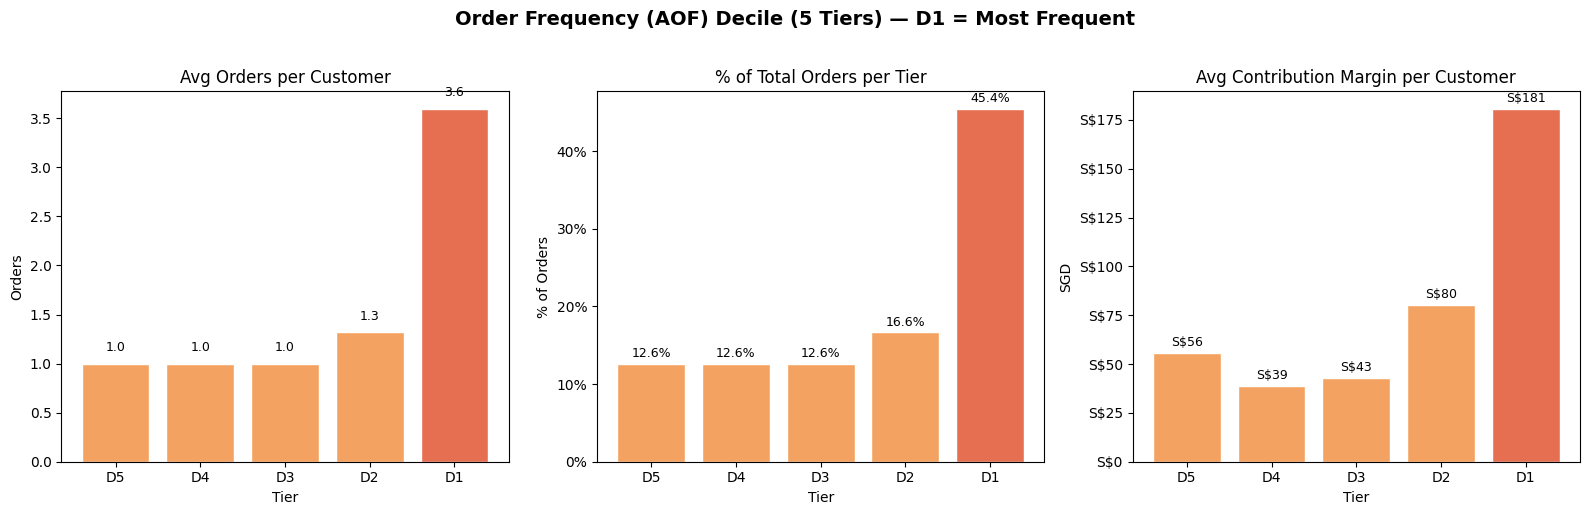

Saved: decile_order_frequency.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Order Frequency (AOF) Decile (5 Tiers) — D1 = Most Frequent", fontsize=14, fontweight="bold", y=1.02)

tiers_f = freq_summary["order_freq_decile"].astype(str)
colors_f = ["#E76F51" if t == "D1" else "#F4A261" for t in tiers_f]

ax = axes[0]
bars = ax.bar(tiers_f, freq_summary["avg_orders"], color=colors_f, edgecolor="white")
ax.set_title("Avg Orders per Customer")
ax.set_xlabel("Tier"); ax.set_ylabel("Orders")
for bar, val in zip(bars, freq_summary["avg_orders"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f"{val:.1f}", ha="center", va="bottom", fontsize=9)

ax = axes[1]
bars = ax.bar(tiers_f, freq_summary["pct_of_total_orders"] * 100, color=colors_f, edgecolor="white")
ax.set_title("% of Total Orders per Tier")
ax.set_xlabel("Tier"); ax.set_ylabel("% of Orders")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
for bar, val in zip(bars, freq_summary["pct_of_total_orders"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{val:.1%}", ha="center", va="bottom", fontsize=9)

ax = axes[2]
bars = ax.bar(tiers_f, freq_summary["avg_cm"], color=colors_f, edgecolor="white")
ax.set_title("Avg Contribution Margin per Customer")
ax.set_xlabel("Tier"); ax.set_ylabel("SGD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"S${x:,.0f}"))
for bar, val in zip(bars, freq_summary["avg_cm"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f"S${val:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FINALS_DIR / "decile_order_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile_order_frequency.png")

## 7. Overlap — Contribution Margin D1 vs Order Frequency D1

D1 contribution margin only : 858 customers (20.0% of pool)
D1 order frequency only : 858 customers (20.0% of pool)
D1 BOTH : 500 customers (11.7% of pool)



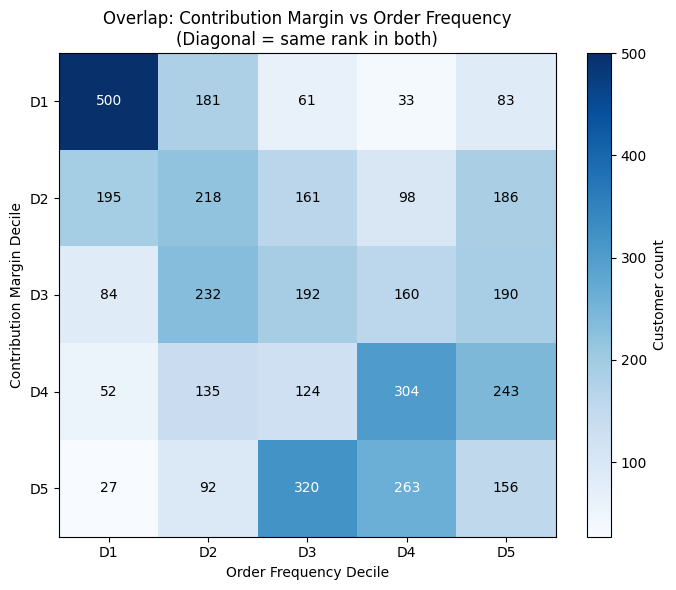

Saved: decile_overlap_heatmap.png


In [22]:
d1_cm   = set(df[df["contribution_margin_decile"] == "D1"]["customer_id"])
d1_freq = set(df[df["order_freq_decile"] == "D1"]["customer_id"])
d1_both = d1_cm & d1_freq

n_pool = len(df)
print(f"D1 contribution margin only : {len(d1_cm):,} customers ({len(d1_cm)/n_pool:.1%} of pool)")
print(f"D1 order frequency only : {len(d1_freq):,} customers ({len(d1_freq)/n_pool:.1%} of pool)")
print(f"D1 BOTH : {len(d1_both):,} customers ({len(d1_both)/n_pool:.1%} of pool)")
print()

# Cross-tab heatmap
cross = pd.crosstab(df["contribution_margin_decile"], df["order_freq_decile"], margins=False)
all_tiers = [f"D{i}" for i in range(1, N_TIERS+1)]
cross = cross.reindex(index=all_tiers, columns=all_tiers, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cross.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="Customer count")
ax.set_xticks(range(N_TIERS)); ax.set_yticks(range(N_TIERS))
ax.set_xticklabels(all_tiers); ax.set_yticklabels(all_tiers)
ax.set_xlabel("Order Frequency Decile")
ax.set_ylabel("Contribution Margin Decile")
ax.set_title("Overlap: Contribution Margin vs Order Frequency\n(Diagonal = same rank in both)")
for i in range(N_TIERS):
    for j in range(N_TIERS):
        val = cross.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center", fontsize=10,
                 color="white" if val > cross.values.max()*0.5 else "black")

plt.tight_layout()
plt.savefig(FINALS_DIR / "decile_overlap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decile_overlap_heatmap.png")

## 8. Export: Customer-Level Decile Table

In [23]:
export_cols = [
    "customer_id",
    "finals_orders", "finals_revenue", "true_gross_profit", "avg_margin_pct", "cogs_coverage_pct",
    "contribution_margin_decile", "order_freq_decile",
]
for col in ["first_channel", "first_product_cat", "first_store", "ever_subscribed",
            "cohort_month", "acq_year", "n_categories_ever"]:
    if col in df.columns:
        export_cols.append(col)

export_df = df[export_cols].copy()
export_df = export_df.sort_values(
    ["contribution_margin_decile", "true_gross_profit"], ascending=[True, False]
)

export_df["is_top_cm"]   = export_df["contribution_margin_decile"] == "D1"
export_df["is_top_freq"] = export_df["order_freq_decile"]          == "D1"
export_df["is_top_both"] = export_df["is_top_cm"] & export_df["is_top_freq"]

for col in ["finals_revenue", "true_gross_profit"]:
    export_df[col] = export_df[col].round(2)
export_df["avg_margin_pct"]    = (export_df["avg_margin_pct"] * 100).round(1)
export_df["cogs_coverage_pct"] = (export_df["cogs_coverage_pct"] * 100).round(1)

out_path = FINALS_DIR / "decile_customer_table.csv"
export_df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Rows: {len(export_df):,}")
print()
print("Preview (top 10 by contribution margin):")
display(export_df[export_df["contribution_margin_decile"]=="D1"].head(10))

Saved: /Users/shwe/Desktop/CustomerAnalytics_Project/lushprotein/EDA/outputs_finals/decile_customer_table.csv
Rows: 4,290

Preview (top 10 by contribution margin):


,customer_id,finals_orders,finals_revenue,true_gross_profit,avg_margin_pct,cogs_coverage_pct,contribution_margin_decile,order_freq_decile,first_channel,first_product_cat,first_store,ever_subscribed,cohort_month,acq_year,n_categories_ever,is_top_cm,is_top_freq,is_top_both
1666,7755957895423,38,4995.46,2796.69,56.0,62.9,D1,D1,Direct / Organic,Unknown,MY,True,2022-03,2022,4,True,True,True
336,6336728531199,3,5542.97,2215.23,40.0,0.0,D1,D1,Subscription,Unknown,SG,False,2022-05,2022,1,True,True,True
619,6558688313599,10,2783.08,1824.82,65.6,53.4,D1,D1,Direct / Organic,Unknown,MY,True,2022-05,2022,3,True,True,True
1736,7756000690431,4,3612.43,1817.95,50.3,29.9,D1,D1,Direct / Organic,Unknown,MY,False,2022-06,2022,2,True,True,True
293,6336631275775,2,4378.26,1751.30,40.0,0.0,D1,D2,Subscription,Unknown,SG,False,2022-04,2022,1,True,False,False
1884,7756026904831,5,4306.38,1722.55,40.0,0.0,D1,D1,Direct / Organic,Unknown,MY,False,2022-02,2022,1,True,True,True
344,6336747438335,5,3180.03,1544.83,48.6,28.1,D1,D1,Subscription,Unknown,SG,False,2022-08,2022,4,True,True,True
3685,8081852530943,7,1933.20,1500.97,77.6,100.0,D1,D1,Direct / Organic,Clear Protein,SG,False,2025-05,2025,3,True,True,True
222,6329689735423,13,2177.98,1431.60,65.7,57.9,D1,D1,Direct / Organic,Unknown,MY,False,2022-03,2022,4,True,True,True
1836,7756016877823,2,2763.27,1105.31,40.0,0.0,D1,D2,Direct / Organic,Unknown,MY,False,2022-08,2022,1,True,False,False


## 9. Summary

In [24]:
print("=" * 65)
print("LUSHPROTEIN DECILE — SUMMARY")
print("=" * 65)
print(f"\nCustomer pool (finals_eligible, excl. all-marketplace): {len(df):,}")
print(f"5 tiers, ~{len(df)//5} customers per tier")

print("\n--- D1: BY CONTRIBUTION MARGIN ---")
d1c = cm_summary[cm_summary["contribution_margin_decile"]=="D1"].iloc[0]
print(f" Customers : {d1c['n_customers']:,}")
print(f" Avg CM : S${d1c['avg_cm']:,.2f}")
print(f" Avg orders : {d1c['avg_orders']:.1f}")
print(f" % of total CM : {d1c['pct_of_total_cm']:.1%}")

print("\n--- D1: BY ORDER FREQUENCY (AOF) ---")
d1f = freq_summary[freq_summary["order_freq_decile"]=="D1"].iloc[0]
print(f"  Customers : {d1f['n_customers']:,}")
print(f"  Avg orders : {d1f['avg_orders']:.1f}")
print(f"  Avg CM : S${d1f['avg_cm']:,.2f}")
print(f"  % of total orders: {d1f['pct_of_total_orders']:.1%}")

print("\n--- OVERLAP ---")
print(f"  D1 in BOTH rankings: {len(d1_both):,} customers")

print("\n--- OUTPUTS ---")
print("  decile_customer_table.csv — full customer-level table, D1-D5 for both metrics")
print("  decile_contribution_margin.png — contribution margin tier charts")
print("  decile_order_frequency.png — order frequency tier charts")
print("  decile_overlap_heatmap.png — cross-tab of the two deciles")
print("=" * 65)

LUSHPROTEIN DECILE — SUMMARY

Customer pool (finals_eligible, excl. all-marketplace): 4,290
5 tiers, ~858 customers per tier

--- D1: BY CONTRIBUTION MARGIN ---
 Customers : 858
 Avg CM : S$230.05
 Avg orders : 3.1
 % of total CM : 57.7%

--- D1: BY ORDER FREQUENCY (AOF) ---
  Customers : 858
  Avg orders : 3.6
  Avg CM : S$180.60
  % of total orders: 45.4%

--- OVERLAP ---
  D1 in BOTH rankings: 500 customers

--- OUTPUTS ---
  decile_customer_table.csv — full customer-level table, D1-D5 for both metrics
  decile_contribution_margin.png — contribution margin tier charts
  decile_order_frequency.png — order frequency tier charts
  decile_overlap_heatmap.png — cross-tab of the two deciles
